## <span style='text-decoration: double underline;color:rgb(10,110,217)'>**Results DiffGoL Model**</span>

**Loss function configuration:**

$\lambda_{init} = 1$  
$\lambda_{phys} = 1$  
$\lambda_{bin} = 1$

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
sys.path.append('../')

In [3]:
import utils.evaluation_tools as eval_tools

delta = 1 
shape = (15,15)
model_name = 'DiffGoL'
parent_folder = '../Data'
seed2plot = 221
seeds = [221, 502, 700, 1204, 3340, 4501, 6054, 6621,8421, 15678, 19302, 38475, 77293, 91827, 99100]  

cols2omit = 1
num_rows = 1

figsize = (12,9)
subplots_grid = (3,3)
suptitle = 'DiffGoL Model'
th_ranges = [(0.45, 0.55), (0.40, 0.60), (0.35, 0.65)]

metrics2compute = ['Accuracy', 'Recall', 'Specificity','Precision', 'F1Score']

train_history_paths = eval_tools.get_paths_results('train_history.csv', parent_folder, seeds, shape, delta, model_name)
predictions_paths = eval_tools.get_paths_results('predictions.csv', parent_folder, seeds, shape, delta, model_name)
test_results_paths = eval_tools.get_paths_results('test_results.csv', parent_folder, seeds, shape, delta, model_name)
test_data = eval_tools.get_paths_results('test.npz', parent_folder, seeds, shape, delta, model_name)

### <span style='color:rgb(10,110,217)'><u>**Train Results**</u></span>

--- Metrics computed during execution ---
loss: 0.6159 ± 0.0029
val_loss: 0.6272 ± 0.0047


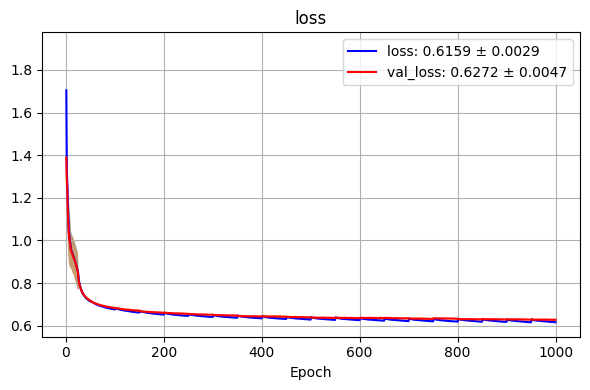

In [4]:
eval_tools.display_results(train_history_paths, 'val_', cols2omit, num_rows, True, True)

### <span style='color:rgb(10,110,217)'><u>**Test Results**</u></span>

Threshold: 0.2612 ± 0.0017


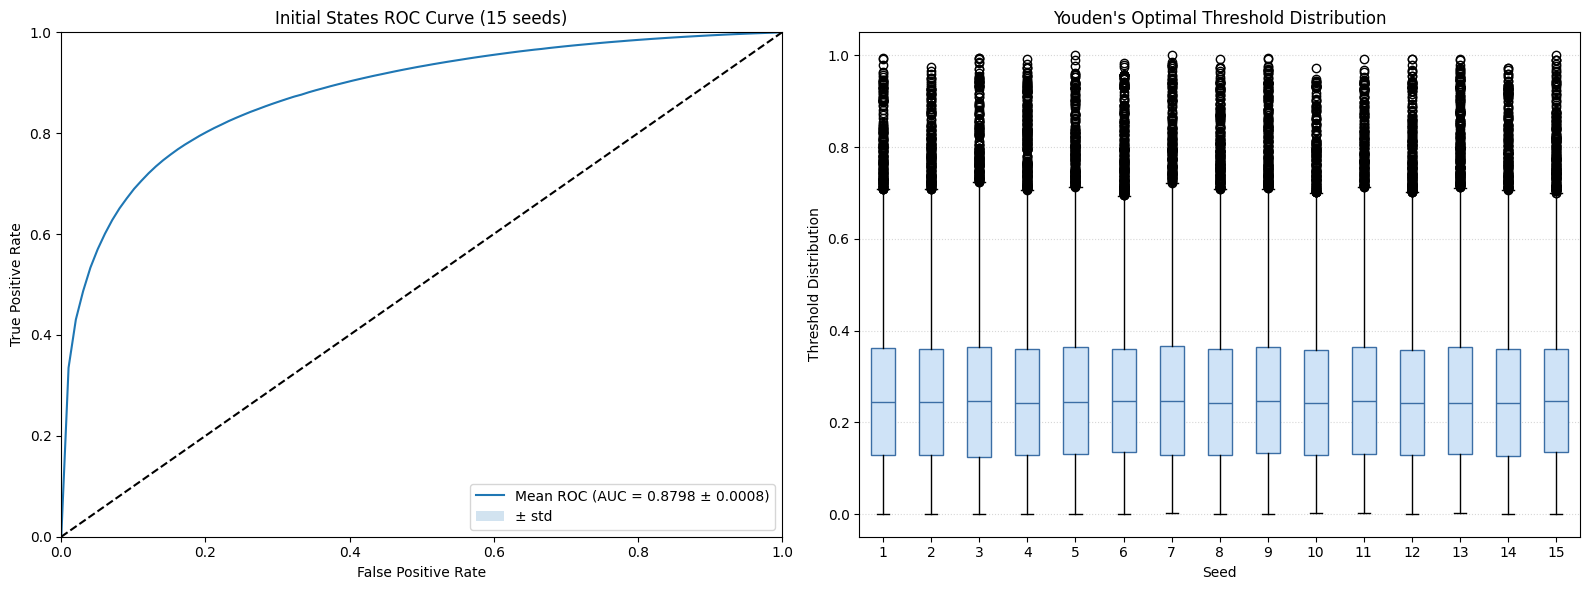

Threshold: 0.1159 ± 0.0025


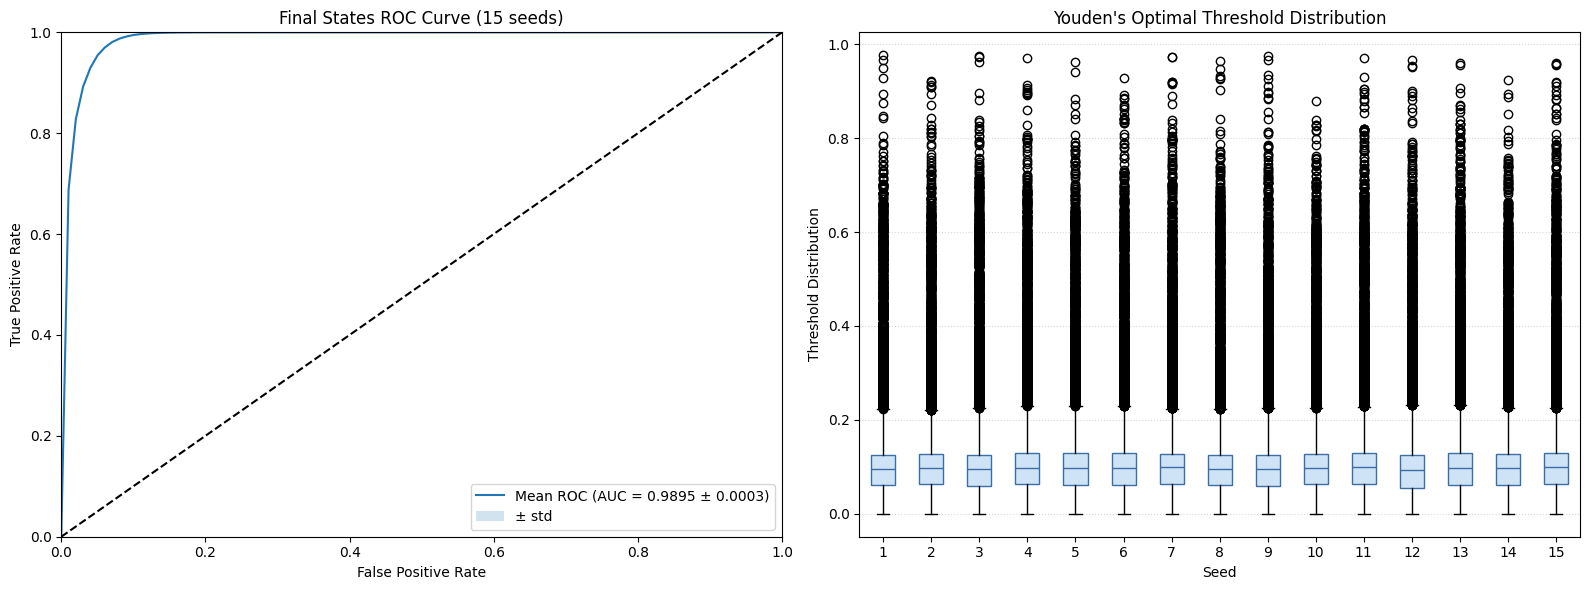

In [5]:
thresholds = eval_tools.computeOtsu(predictions_paths, 'init', shape)
threshold, init_thresholds = eval_tools.computeROC(predictions_paths, test_data, 'init', shape)
threshold_fin, fin_thresholds = eval_tools.computeROC(predictions_paths, test_data, 'fin', shape)

In [7]:
eval_tools.computeCM(predictions_paths, test_data, metrics2compute, init_thresholds, shape, 'init')
print('')
eval_tools.computeCM(predictions_paths, test_data, metrics2compute, fin_thresholds, shape, 'fin')

--- Results Initial states (15 seeds) ---
Accuracy: 0.8253 ± 0.0008
Recall: 0.8042 ± 0.0014
Specificity: 0.8337 ± 0.0010
Precision: 0.6015 ± 0.0017
F1Score: 0.6760 ± 0.0016

--- Results Final states (15 seeds) ---
Accuracy: 0.9668 ± 0.0005
Recall: 0.9693 ± 0.0002
Specificity: 0.9614 ± 0.0007
Precision: 0.9014 ± 0.0016
F1Score: 0.9329 ± 0.0009


In [8]:
eval_tools.computeCM_OTSU(predictions_paths, test_data, metrics2compute, thresholds, shape, 'init')
print('')
eval_tools.computeCM_OTSU(predictions_paths, test_data, metrics2compute, thresholds, shape, 'fin')

--- Results Initial states (15 seeds) ---
Accuracy: 0.8498 ± 0.0006
Recall: 0.6934 ± 0.0027
Specificity: 0.8979 ± 0.0009
Precision: 0.6802 ± 0.0013
F1Score: 0.6847 ± 0.0016

--- Results Final states (15 seeds) ---
Accuracy: 0.9164 ± 0.0009
Recall: 0.7036 ± 0.0041
Specificity: 0.9897 ± 0.0003
Precision: 0.9547 ± 0.0012
F1Score: 0.8028 ± 0.0028


In [9]:
# Test:
eval_tools.display_results(test_results_paths, '_fin', display_plot=False)

--- Metrics computed during execution ---
Accuracy_init: 0.8528 ± 0.0005
Accuracy_fin: 0.9057 ± 0.0009
Recall_init: 0.6396 ± 0.0030
Recall_fin: 0.5990 ± 0.0043
Specificity_init: 0.9143 ± 0.0008
Specificity_fin: 0.9922 ± 0.0002
Precision_init: 0.6828 ± 0.0012
Precision_fin: 0.9557 ± 0.0013
F1Score_init: 0.6605 ± 0.0016
F1Score_fin: 0.7365 ± 0.0033


--- Results Initial States (15 seeds) ---
Density (true): 22.39% ± 9.39%
Density (pred): 23.86% ± 9.66%
Error/seed:     1.47% ± 0.06%
Max value predicted: 1.0000
HUC% (0.45, 0.55): 2.36% ± 0.04%
HUC% (0.4, 0.6): 4.84% ± 0.07%
HUC% (0.35, 0.65): 7.57% ± 0.09%
Fuzziness Index: 0.2801 ± 0.1450
MSE (prob):0.1106 ± 0.0651
MSE (bin):0.1765 ± 0.1020
MSE (all-zero): 0.2239 ± 0.0939
Wasserstein (EMD): 1.3396 ± 0.0032


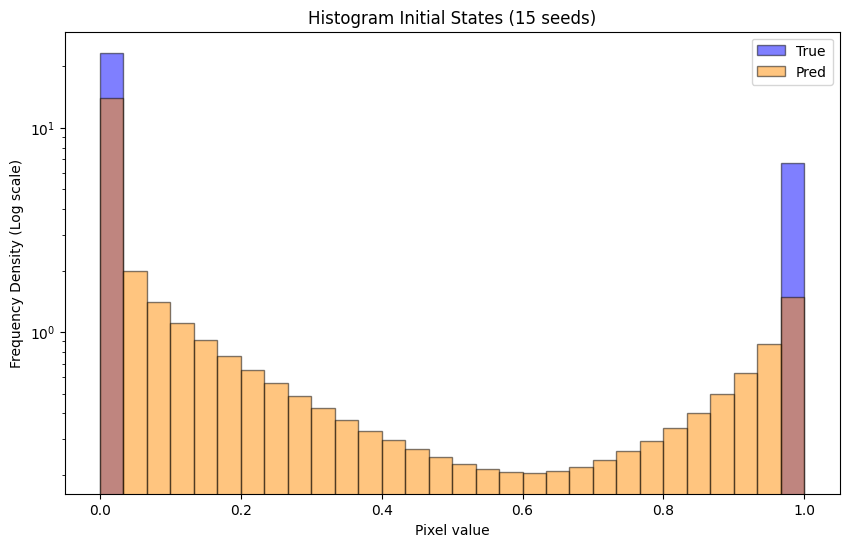

In [10]:
eval_tools.compute_metrics(predictions_paths, test_data,shape,'init', th_ranges, threshold, colors=['blue', 'darkorange'])

--- Results Final States (15 seeds) ---
Density (true): 22.00% ± 9.81%
Density (pred): 13.40% ± 5.02%
Error/seed:     8.60% ± 0.06%
Max value predicted: 1.0000
HUC% (0.45, 0.55): 2.54% ± 0.03%
HUC% (0.4, 0.6): 5.09% ± 0.06%
HUC% (0.35, 0.65): 7.67% ± 0.08%
Fuzziness Index: 0.1777 ± 0.0917
MSE (prob):0.0618 ± 0.0400
MSE (bin):0.0527 ± 0.0386
MSE (all-zero): 0.2200 ± 0.0981
Wasserstein (EMD): 1.3831 ± 0.0050


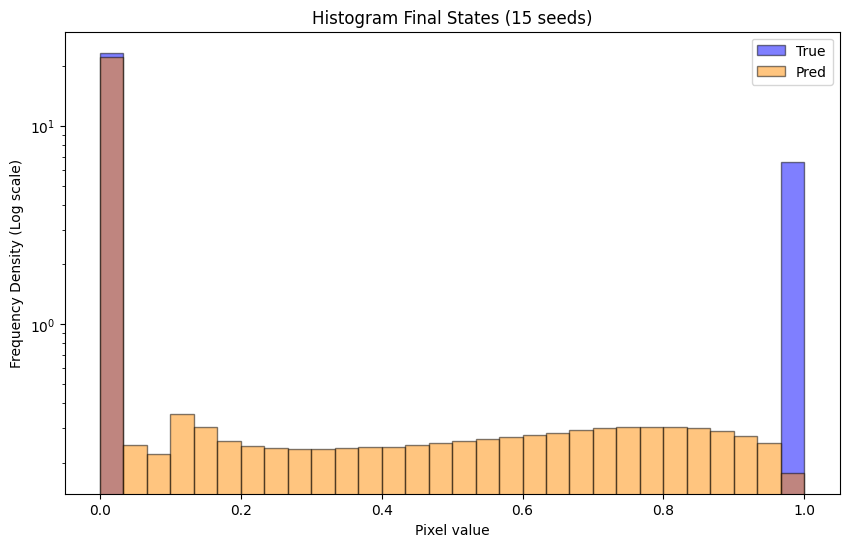

In [11]:
eval_tools.compute_metrics(predictions_paths, test_data,shape,'fin', th_ranges, threshold, colors=['blue', 'darkorange'])

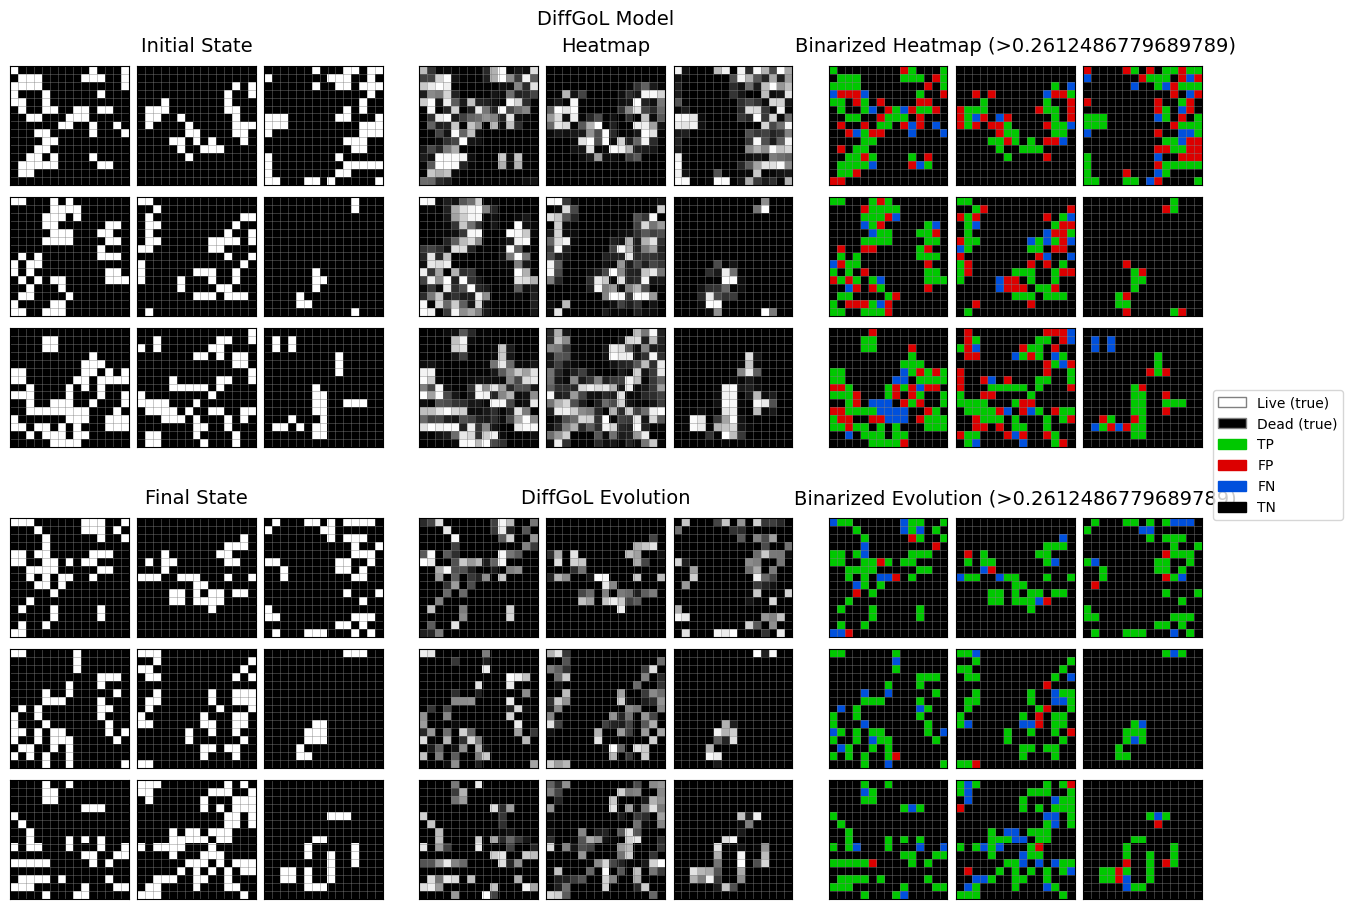

In [12]:
file_test = test_data[seed2plot]
file_pred = predictions_paths[seed2plot]
titles = ['Initial State', 'Heatmap', f'Binarized Heatmap (>{threshold})', 
          'Final State', 'DiffGoL Evolution', f'Binarized Evolution (>{threshold})']
eval_tools.display_states(file_pred, file_test, shape, threshold, titles, subplots_grid, suptitle, figsize, random=False) 